Saving pneumologista_joao_pacientes.csv to pneumologista_joao_pacientes (27).csv
Colunas: ['nome_paciente', 'idade', 'sexo', 'tabagismo', 'descoloracao_dedos', 'estresse_mental', 'exposicao_poluicao', 'doenca_cronica', 'nivel_energia', 'fraqueza_imunologica', 'problema_respiratorio', 'consumo_alcool', 'desconforto_garganta', 'saturacao_oxigenio', 'aperto_peito', 'historico_familiar', 'historico_tabagismo_familiar', 'estresse_imunologico', 'doenca_pulmonar', 'peso_kg', 'altura_m', 'imc', 'risco_cancer_pulmao']

Primeiras linhas:
   nome_paciente  idade   sexo tabagismo descoloracao_dedos estresse_mental  \
0      Ana Silva     54      F       Não                Não           Baixo   
1   Mariana Lima     38   Masc       Não                Não        Moderado   
2  Tiago Barbosa     50   Masc       Não                Não            Alto   
3   Carlos Alves     56      M       Não                Não           Baixo   
4    Paula Costa     18  Outro       Sim                Não           B

/tmp/ipykernel_550/1455731468.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_550/1455731468.py:52: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(
/tmp/ipykernel_550/1455731468.py:58: FutureWarning: Downcastin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Arquivo 'dados_limpos.csv' gerado com sucesso!


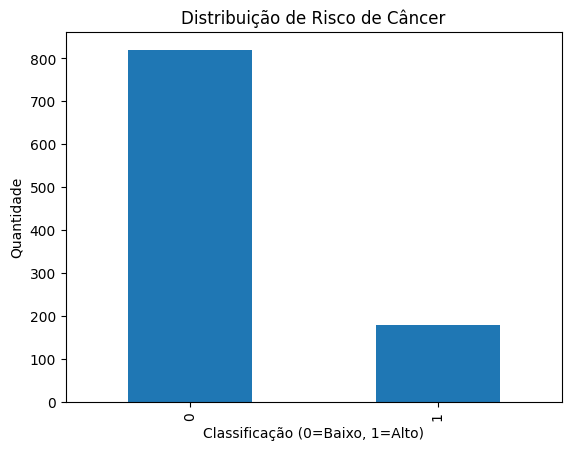

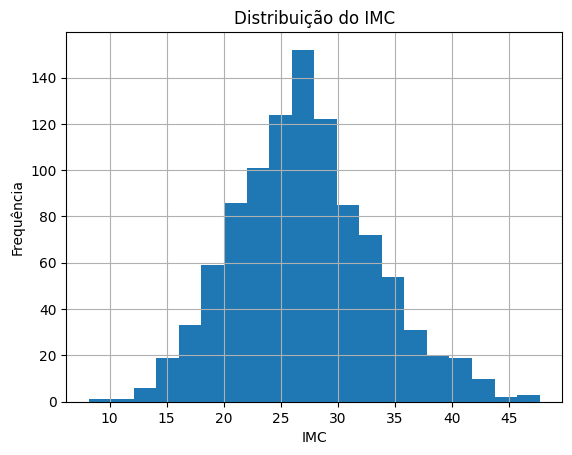


📊 Estatísticas do IMC:
Média: 27.148497523517307
Desvio padrão: 6.103901970551596
Acurácia Treino: 0.8175
Acurácia Teste: 0.825


In [33]:
# importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#importação para o Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Carregar os dados
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
print("Colunas:", df.columns.tolist())
print("\nPrimeiras linhas:")
print(df.head())

# Tratamentos de dados
# Padronizar textos minuscuos e sem espaços
colunas_objeto = df.select_dtypes(include=['object']).columns
for col in colunas_objeto:
  df[col] = df[col].astype(str).str.lower().str.strip()

# tratar valores nulos (numericos)
cols_numericas = ['saturacao_oxigenio', 'peso_kg', 'altura_m']
for col in cols_numericas:
  if col in df.columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Criar e recalcular IMC
if 'peso_kg' in df.columns and 'altura_m' in df.columns:
  df['imc'] = df['peso_kg'] / (df['altura_m'] ** 2)

# Converter  o sexo
if 'sexo' in df.columns:
    df['sexo'] = df['sexo'].replace(
        {'m': 'masculino', 'f': 'feminino'}
    )
# Converter colunas binárias (Sim/Não → 1/0)
colunas_binarias = [
    'tabagismo','descoloracao_dedos','estresse_mental',
    'exposicao_poluicao','doenca_cronica','fraqueza_imunologica',
    'problema_respiratorio','consumo_alcool','desconforto_garganta',
    'aperto_peito','historico_familiar','historico_tabagismo_familiar',
    'estresse_imunologico','doenca_pulmonar'
]

for col in colunas_binarias:
    if col in df.columns:
        df[col] = df[col].replace(
            {'sim': 1, 'não': 0, 'nao': 0}
        )

# Converter risco (padronizar)
if 'risco_cancer_pulmao' in df.columns:
    df['risco_cancer_pulmao'] = df['risco_cancer_pulmao'].replace({
        'alto': 1,
        'baixo': 0,
        'sim': 1,
        'não': 0,
        'nao': 0,
        'risco': 1,       # Corrected mapping
        'sem risco': 0    # Corrected mapping
    })

#  Converter tudo que for possível para número
df = df.apply(pd.to_numeric, errors='ignore')

#  Remover duplicados
df.drop_duplicates(inplace=True)

# =========================
# 4. SALVAR BASE LIMPA
# =========================
df.to_csv('dados_limpos.csv', index=False)

# Download automático
files.download('dados_limpos.csv')

print("\n Arquivo 'dados_limpos.csv' gerado com sucesso!")


#  ANÁLISE E GRÁFICOS


#  Gráfico de barras (risco)
if 'risco_cancer_pulmao' in df.columns:
    df['risco_cancer_pulmao'].value_counts().plot(kind='bar')
    plt.title('Distribuição de Risco de Câncer')
    plt.xlabel('Classificação (0=Baixo, 1=Alto)')
    plt.ylabel('Quantidade')
    plt.show()

#  Histograma do IMC
if 'imc' in df.columns:
    df['imc'].hist(bins=20)
    plt.title('Distribuição do IMC')
    plt.xlabel('IMC')
    plt.ylabel('Frequência')
    plt.show()

#  ESTATÍSTICAS


if 'imc' in df.columns:
    print("\n📊 Estatísticas do IMC:")
    print("Média:", np.mean(df['imc']))
    print("Desvio padrão:", np.std(df['imc']))

# features
X = df[['idade','sexo','imc','saturacao_oxigenio']]
y = df['risco_cancer_pulmao']

# one-hot encode 'sexo' column
X = pd.get_dummies(X, columns=['sexo'], drop_first=True) # Corrected 'x' to 'X'

# Divisão
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# Previsões
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

# Acurácia
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print("Acurácia Treino:", acc_train)
print("Acurácia Teste:", acc_test)
